# Лабораторна робота №2: фільтрація й придушення шумів

У цьому ноутбуку виконується повний цикл: завантаження тестового зображення, моделювання **гаусівського** та **імпульсного (сіль і перець)** шуму, застосування **усереднювального**, **гаусівського**, **медіанного** та **вінерівського** фільтрів, збереження результатів у `results/` та підсумкова порівняльна фігура.


## 1. Імпорт бібліотек

Підключаємо роботу з шляхами (`pathlib`), масивами (`numpy`), OpenCV (`cv2`), візуалізацію (`matplotlib.pyplot`) та **вінерівський фільтр** з `scipy.signal.wiener`.

**Очікуваний результат:** усі модулі імпортуються без помилок.


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal

# Відтворювані експерименти для звіту
np.random.seed(42)


## 2. Налаштування шляхів

- `NOTEBOOK_DIR` — папка з `Lab_02.ipynb` (визначається від `Path.cwd()`, щоб коректно працювало й у Jupyter, і при `nbconvert` з кореня репозиторію);
- `ROOT` — корінь репозиторію (`NOTEBOOK_DIR.parent`);
- `IMAGE_PATH` — вхідне зображення `satir.jpg`;
- `RESULTS_DIR` — `NOTEBOOK_DIR / "results"` для PNG-результатів.

**Очікуваний результат:** шляхи коректні, папка `results` створюється автоматично.


In [2]:
_cwd = Path.cwd().resolve()
NOTEBOOK_DIR = _cwd if (_cwd / "Lab_02.ipynb").is_file() else (_cwd / "Lab_02")
ROOT = NOTEBOOK_DIR.parent.resolve()
IMAGE_PATH = ROOT / "satir.jpg"
RESULTS_DIR = (NOTEBOOK_DIR / "results").resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("ROOT:", ROOT)
print("IMAGE_PATH:", IMAGE_PATH)
print("RESULTS_DIR:", RESULTS_DIR)


NOTEBOOK_DIR: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_02
ROOT: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP
IMAGE_PATH: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\satir.jpg
RESULTS_DIR: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_02\results


## 3. Допоміжні функції та завантаження зображення

На Windows `cv2.imread` може не відкрити файл, якщо у шляху є кирилиця. Використовуємо **`numpy.fromfile` + `cv2.imdecode`** для читання та **`cv2.imencode` + `tofile`** для запису.

**Очікуваний результат:** зображення завантажується у градаціях сірого; далі всі операції — над 2D-масивом `uint8`.


In [3]:
def imread_gray_unicode(path: Path) -> np.ndarray:
    """Завантаження зображення у градаціях сірого (коректні Unicode-шляхи)."""
    data = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Не вдалося прочитати: {path}")
    return img


def imwrite_unicode(path: Path, img: np.ndarray) -> None:
    """Збереження PNG/JPEG з коректним шляхом на Windows."""
    ok, buf = cv2.imencode(path.suffix, img)
    if not ok:
        raise RuntimeError(f"Не вдалося закодувати: {path}")
    buf.tofile(str(path))


img_original = imread_gray_unicode(IMAGE_PATH)
print("Розмір зображення:", img_original.shape, "dtype:", img_original.dtype)


Розмір зображення: (640, 426) dtype: uint8


## 4. Оригінал у градаціях сірого

Показуємо вихідне зображення без шуму та зберігаємо копію для звіту.

**Очікуваний результат:** чітке напівтонове зображення. Шуму ще немає — це еталон для порівняння.


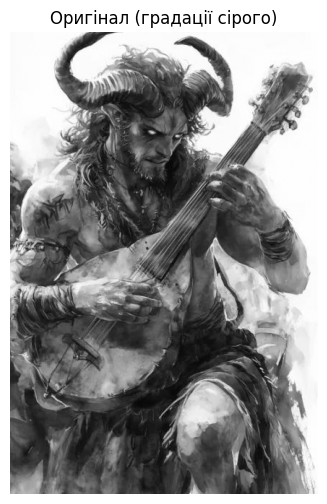

Збережено: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_02\results\original_gray.png


In [4]:
plt.figure(figsize=(6, 6))
plt.imshow(img_original, cmap="gray")
plt.title("Оригінал (градації сірого)")
plt.axis("off")
plt.show()

imwrite_unicode(RESULTS_DIR / "original_gray.png", img_original)
print("Збережено:", RESULTS_DIR / "original_gray.png")


## 5. Гаусівський шум

**Що робить блок:** додає до кожного пікселя випадкову величину з нормального розподілу \(\mathcal{N}(\mu, \sigma^2)\), після чого значення обрізаються до \([0, 255]\).

**Очікуваний результат:** зерниста «плівка» по всьому кадру; дрібні деталі стають менш читабельними.

**Чому так:** гаусівський шум моделює тепловий/сенсорний шум; для нього добре працюють **згладжувальні** фільтри (усереднення, гаусівське згладжування, Вінер), але вони часто **розмивають різкі границі**.


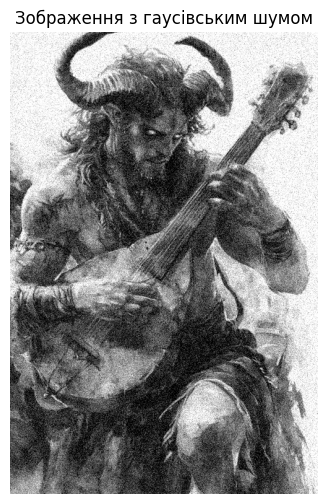

Збережено: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_02\results\gaussian_noise.png


In [5]:
def add_gaussian_noise(image: np.ndarray, mean: float = 0, sigma: float = 25) -> np.ndarray:
    """Додає гаусівський шум до зображення (uint8 -> float -> clip -> uint8)."""
    noise = np.random.normal(mean, sigma, image.shape)
    noisy = image.astype(np.float64) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)


img_gaussian_noise = add_gaussian_noise(img_original, mean=0, sigma=25)

plt.figure(figsize=(6, 6))
plt.imshow(img_gaussian_noise, cmap="gray")
plt.title("Зображення з гаусівським шумом")
plt.axis("off")
plt.show()

imwrite_unicode(RESULTS_DIR / "gaussian_noise.png", img_gaussian_noise)
print("Збережено:", RESULTS_DIR / "gaussian_noise.png")


## 6. Шум «сіль і перець»

**Що робить блок:** випадково змінює частку пікселів на максимум (255, «сіль») або мінімум (0, «перець»).

**Очікуваний результат:** рідкісні яскраві та темні імпульси на тлі зображення.

**Чому так:** це **імпульсний** шум; **усереднювальний** фільтр розмазує імпульс по сусідах і погано його прибирає. **Медіанний** фільтр замінює викид медіаною вікна й набагато ефективніший для «солі-перцю».


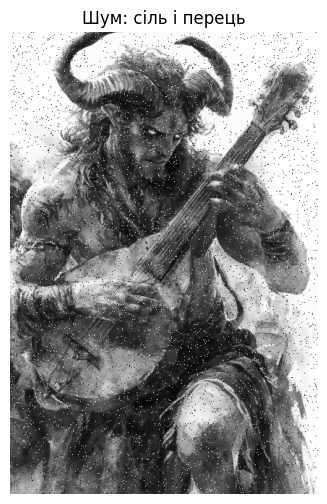

Збережено: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_02\results\salt_pepper_noise.png


In [6]:
def add_salt_pepper_noise(
    image: np.ndarray, amount: float = 0.04, salt_vs_pepper: float = 0.5
) -> np.ndarray:
    """Імпульсний шум: частка `amount` пікселів стає 255 або 0."""
    out = image.copy()
    h, w = image.shape
    total = int(round(amount * h * w))
    n_salt = int(round(total * salt_vs_pepper))
    n_pepper = total - n_salt

    ys = np.random.randint(0, h, n_salt)
    xs = np.random.randint(0, w, n_salt)
    out[ys, xs] = 255

    ys = np.random.randint(0, h, n_pepper)
    xs = np.random.randint(0, w, n_pepper)
    out[ys, xs] = 0
    return out


img_salt_pepper = add_salt_pepper_noise(img_original, amount=0.04, salt_vs_pepper=0.5)

plt.figure(figsize=(6, 6))
plt.imshow(img_salt_pepper, cmap="gray")
plt.title("Шум: сіль і перець")
plt.axis("off")
plt.show()

imwrite_unicode(RESULTS_DIR / "salt_pepper_noise.png", img_salt_pepper)
print("Збережено:", RESULTS_DIR / "salt_pepper_noise.png")


## 7. Фільтрація зображення з гаусівським шумом

Застосовуємо:

- **Усереднювальний 3×3 / 5×5** — рівномірне згладжування; шум зменшується, але зростає розмиття.
- **Гаусівський фільтр** — згладжування з вагами Гауса; зазвичай м’якше за рівномірне усереднення того ж розміру.
- **Вінерівський фільтр** (`scipy.signal.wiener`) — оцінює локальну статистику й намагається відновити сигнал з урахуванням шуму.

**Очікуваний результат:** зменшення зернистості; **5×5 усереднення** сильніше розмиває, ніж **3×3**; Вінер часто зберігає деталі краще за просте згладжування (залежить від `mysize`).


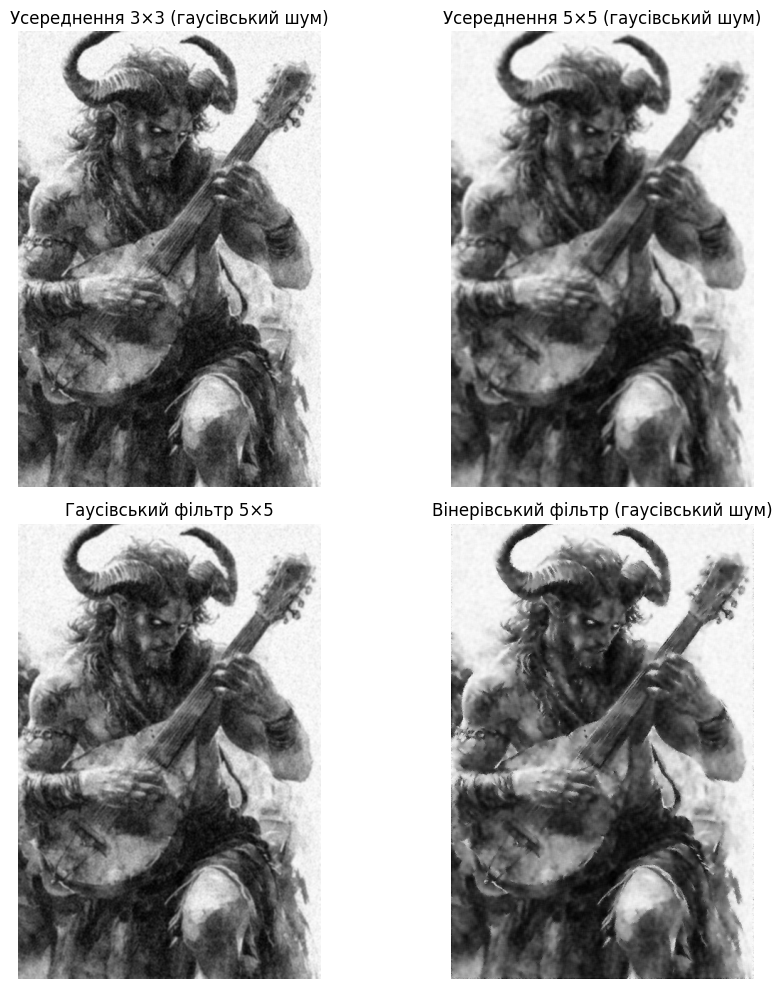

Збережено фільтри для гаусівського шуму.


In [7]:
img_avg3_g = cv2.blur(img_gaussian_noise, (3, 3))
img_avg5_g = cv2.blur(img_gaussian_noise, (5, 5))
img_gauss_filt = cv2.GaussianBlur(img_gaussian_noise, (5, 5), 0)

img_wiener_g = scipy.signal.wiener(img_gaussian_noise.astype(np.float64), mysize=(5, 5))
img_wiener_g = np.clip(img_wiener_g, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, im, title in zip(
    axes.ravel(),
    [img_avg3_g, img_avg5_g, img_gauss_filt, img_wiener_g],
    [
        "Усереднення 3×3 (гаусівський шум)",
        "Усереднення 5×5 (гаусівський шум)",
        "Гаусівський фільтр 5×5",
        "Вінерівський фільтр (гаусівський шум)",
    ],
):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

imwrite_unicode(RESULTS_DIR / "average_3x3_gaussian.png", img_avg3_g)
imwrite_unicode(RESULTS_DIR / "average_5x5_gaussian.png", img_avg5_g)
imwrite_unicode(RESULTS_DIR / "gaussian_filter.png", img_gauss_filt)
imwrite_unicode(RESULTS_DIR / "wiener_filter_gaussian.png", img_wiener_g)
print("Збережено фільтри для гаусівського шуму.")


## 8. Фільтрація зображення з шумом «сіль і перець»

- **Медіанний фільтр 3×3 / 5×5** — заміна пікселя медіаною в окні; ефективно прибирає імпульси.
- **Усереднювальний фільтр 5×5** (для порівняння) — імпульс «розмазується», залишаються плями та сильне розмиття.

**Очікуваний результат:** медіана суттєво очищує зображення; усереднення виглядає гірше на імпульсному шумі.


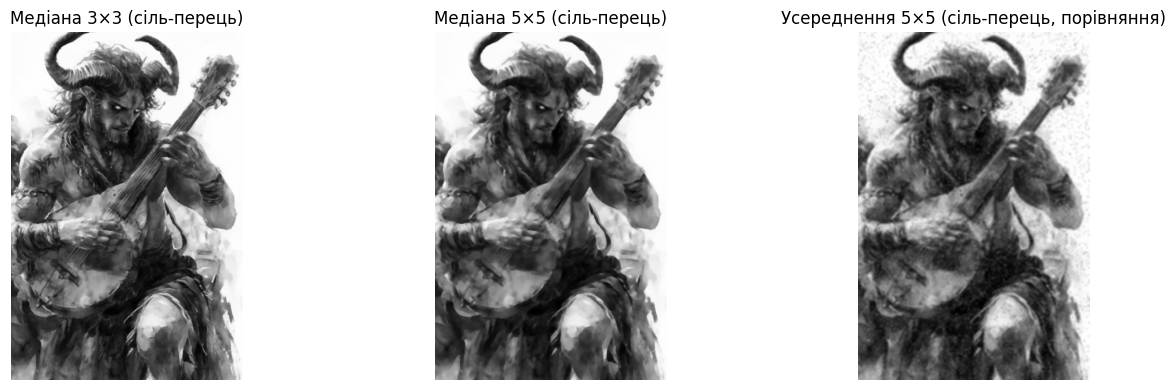

Збережено фільтри для шуму сіль-перець.


In [8]:
img_med3_sp = cv2.medianBlur(img_salt_pepper, 3)
img_med5_sp = cv2.medianBlur(img_salt_pepper, 5)
img_avg_sp = cv2.blur(img_salt_pepper, (5, 5))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, im, title in zip(
    axes,
    [img_med3_sp, img_med5_sp, img_avg_sp],
    [
        "Медіана 3×3 (сіль-перець)",
        "Медіана 5×5 (сіль-перець)",
        "Усереднення 5×5 (сіль-перець, порівняння)",
    ],
):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

imwrite_unicode(RESULTS_DIR / "median_3x3_salt_pepper.png", img_med3_sp)
imwrite_unicode(RESULTS_DIR / "median_5x5_salt_pepper.png", img_med5_sp)
imwrite_unicode(RESULTS_DIR / "average_salt_pepper.png", img_avg_sp)
print("Збережено фільтри для шуму сіль-перець.")


## 9. Порівняльна фігура

Зводимо на одній сітці **оригінал**, **гаусівський шум**, результати фільтрації гаусівського шуму (**усереднення 3×3**, **гаусівський фільтр**, **Вінер**), **шум сіль-перець** та **медіани 3×3 і 5×5**.

**Очікуваний результат:** наочно видно різницю між згладжуванням гаусівського шуму та придушенням імпульсного медіаною.


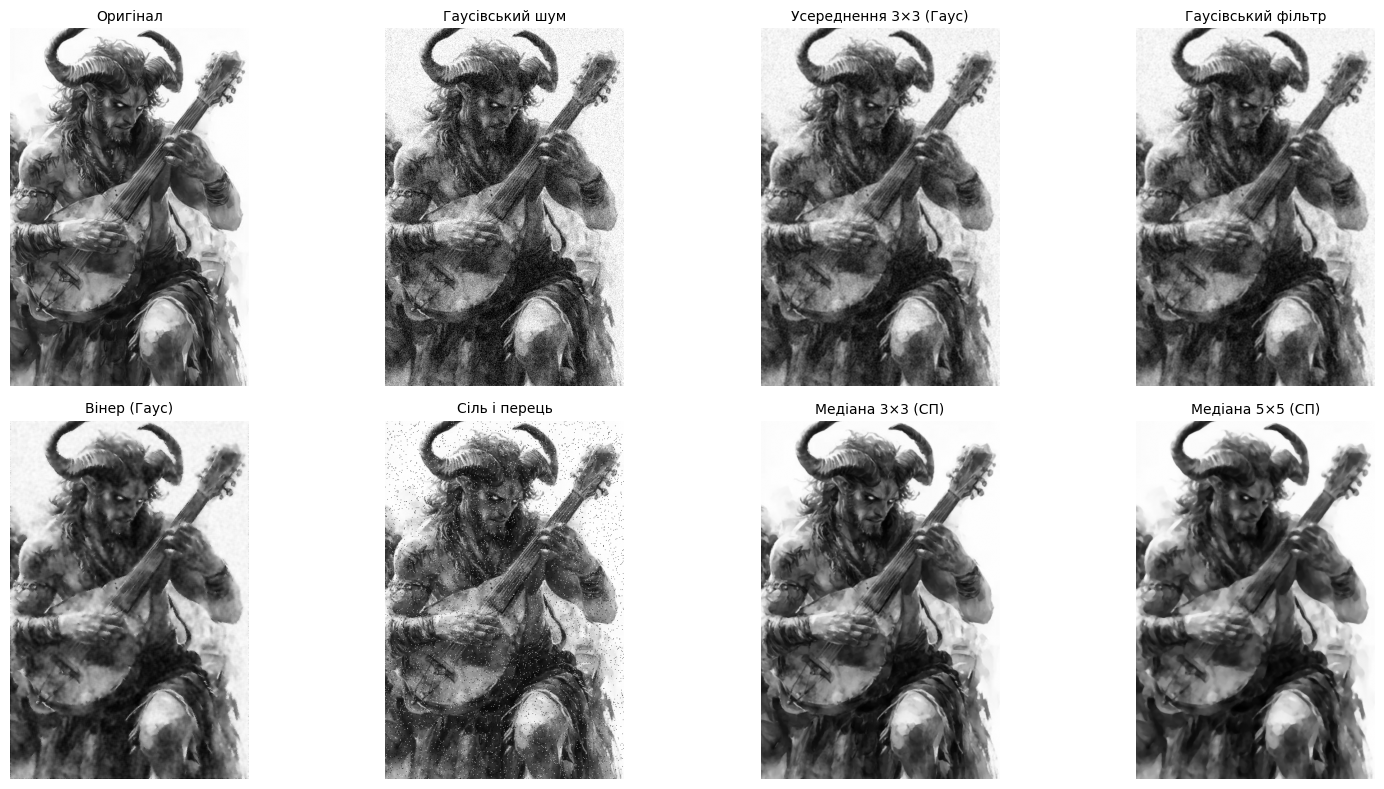

Збережено: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_02\results\comparison.png


In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
items = [
    (img_original, "Оригінал"),
    (img_gaussian_noise, "Гаусівський шум"),
    (img_avg3_g, "Усереднення 3×3 (Гаус)"),
    (img_gauss_filt, "Гаусівський фільтр"),
    (img_wiener_g, "Вінер (Гаус)"),
    (img_salt_pepper, "Сіль і перець"),
    (img_med3_sp, "Медіана 3×3 (СП)"),
    (img_med5_sp, "Медіана 5×5 (СП)"),
]
for ax, (im, title) in zip(axes.ravel(), items):
    ax.imshow(im, cmap="gray")
    ax.set_title(title, fontsize=10)
    ax.axis("off")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "comparison.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Збережено:", RESULTS_DIR / "comparison.png")


## Підсумок

Усі етапи виконано: змодельовано два типи шуму, застосовано набір фільтрів, збережено PNG у `results/` та побудовано `comparison.png`. Детальні висновки та відповіді на контрольні питання — у файлі `report.md`.
